# 01 — Run your first Robot SF episode

This notebook runs a short, **fully deterministic** episode in a Robot SF
navigation environment using a random policy, then plots the per-step reward.

**You will learn how to:**
1. Build a robot navigation environment with the factory function.
2. Reset it and step it with random actions.
3. Read the reward signal and plot it with matplotlib.

> CPU-only, headless, no rendering window, no training. Runs in a few seconds.
>
> It mirrors the canonical example at
> `examples/quickstart/01_basic_robot.py`.

In [1]:
# Headless setup: no GUI window. We deliberately do NOT force a matplotlib
# backend here, because several robot_sf modules call matplotlib.use("Agg",
# force=True) at import time and would clobber an inline backend set now.
# Instead each plotting cell re-enables the inline backend right before it
# draws, so figures still render into the notebook output under nbconvert.
import os
import sys
from IPython import get_ipython

os.environ.setdefault("SDL_VIDEODRIVER", "dummy")


def _inline_matplotlib() -> None:
    # (Re-)arm the notebook inline backend for the next figure.
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")


# Keep log output quiet so the executed notebook stays readable.
from loguru import logger
logger.remove()
logger.add(sys.stderr, level="ERROR")

from pathlib import Path

import matplotlib.pyplot as plt

from robot_sf.common.seed import set_global_seed
from robot_sf.gym_env.environment_factory import make_robot_env

# Resolve the repo root robustly regardless of the working directory this
# notebook is launched from (repo root, or its own notebooks/ folder).
def _repo_root() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here

REPO_ROOT = _repo_root()

# Where this notebook writes its small artifact (git-ignored).
OUTPUT_DIR = REPO_ROOT / "output/notebooks/01_run_first_episode"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO_ROOT)
print("Artifacts will be written to:", OUTPUT_DIR.relative_to(REPO_ROOT))

I0000 00:00:1784157892.085090 1036722 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784157892.116292 1036722 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784157892.683903 1036722 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784157892.684101 1036722 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Repo root: /home/luttkule/git/robot_sf_ll7.worktrees/cheap-issue-5798-20260715T225820Z
Artifacts will be written to: output/notebooks/01_run_first_episode


## 1. Build and reset the environment

`make_robot_env()` is the ergonomic entry point. We seed everything for reproducibility.

In [2]:
SEED = 87234
set_global_seed(SEED)

env = make_robot_env(debug=False)
observation, info = env.reset()
print("Environment created and reset.")
print("Observation type:", type(observation).__name__)
if hasattr(observation, "keys"):
    print("Observation keys:", list(observation.keys()))
print("Action space:", env.action_space)

Environment created and reset.
Observation type: dict
Observation keys: ['drive_state', 'rays']
Action space: Box(-1.0, 1.0, (2,), float32)


## 2. Step the environment with random actions

Each call to `env.step(action)` returns the Gymnasium 5-tuple
`(observation, reward, terminated, truncated, info)`. We collect the
reward at every step. If the episode ends early (collision or success),
we reset and keep going so the budget is filled.

In [3]:
N_STEPS = 60
rewards = []
collisions = 0

for step in range(1, N_STEPS + 1):
    action = env.action_space.sample()  # random policy
    observation, reward, terminated, truncated, info = env.step(action)
    rewards.append(float(reward))
    if bool(info.get("collision")):
        collisions += 1
    if terminated or truncated:
        observation, info = env.reset()

print(f"Stepped {N_STEPS} times.")
print(f"Total reward: {sum(rewards):.3f}")
print(f"Collisions: {collisions}")

Stepped 60 times.
Total reward: -4.957
Collisions: 0


## 3. Plot the reward over time

We save the figure to `output/` and also display it inline.

Saved: output/notebooks/01_run_first_episode/reward_curve.png


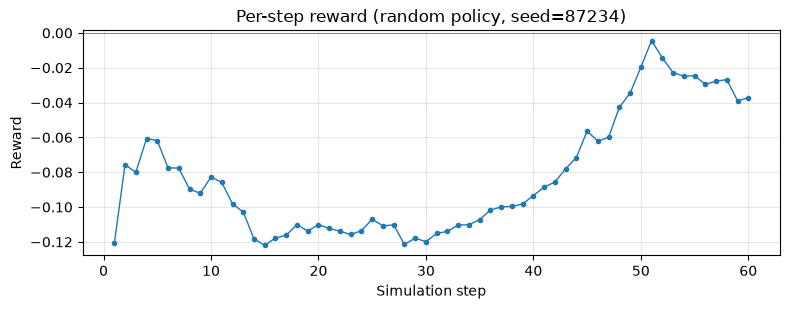

In [4]:
_inline_matplotlib()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(range(1, N_STEPS + 1), rewards, marker=".", linewidth=1)
ax.axhline(0.0, color="black", linewidth=0.6, alpha=0.5)
ax.set_xlabel("Simulation step")
ax.set_ylabel("Reward")
ax.set_title(f"Per-step reward (random policy, seed={SEED})")
ax.grid(True, alpha=0.3)
fig.tight_layout()

plot_path = OUTPUT_DIR / "reward_curve.png"
fig.savefig(plot_path, dpi=120)
print("Saved:", plot_path.relative_to(REPO_ROOT))
plt.show()

## Done

You built an environment, ran a deterministic episode, and inspected the
reward signal. Next, try **02 — Compare two planners** to see how two
different navigation strategies behave, or **03 — Visualize a trace** to
watch an episode as an interactive viewer + trajectory plot.

In [5]:
# Always release the environment's resources when finished.
env.exit()
print("Environment closed. Notebook 01 complete.")

Environment closed. Notebook 01 complete.
